# Demo: Model And Artifact Persistence

This notebook is a standalone persistence and tuning workflow demo built on a small public sample dataset kept in this repo. It focuses on reproducible save/load behaviour for datasets, baseline models, and tuning artefacts while keeping the search spaces small enough for a live walkthrough.

The execution flow for each artefact type follows one precedence rule throughout the notebook:

`OVERWRITE` > `LOAD` > create/train/tune fresh

## Colab / Local Setup

Local execution works from the cloned repo in VS Code, Jupyter, or WSL.

In Google Colab, start each new runtime by cloning the repo into `/content/ml-model-persistence-demo`, installing dependencies, and then running the setup cell below:

```bash
!git clone <repo-url> /content/ml-model-persistence-demo
%cd /content/ml-model-persistence-demo
!pip install -r requirements.txt
```

If you clone into a different folder name, set `COLAB_PROJECT_REPO` before running the setup cell.

In [27]:

# ============================================================
# ENVIRONMENT / COLAB SETUP
# ============================================================

import os
import sys
from pathlib import Path


# ----------------------------
# User settings
# ----------------------------
CLONE_REPO = True
INSTALL_REQUIREMENTS = True
USE_GOOGLE_DRIVE_ARTIFACTS = False
GOOGLE_DRIVE_ARTIFACT_ROOT = Path('/content/drive/MyDrive/ml-model-persistence-demo/demo_artifacts')

REPO_NAME = os.environ.get("COLAB_PROJECT_REPO", "ml-model-persistence-demo")
REPO_URL = f"https://github.com/ATDiDonato/{REPO_NAME}.git"
COLAB_REPO_DIR = Path('/content') / REPO_NAME

MINIMAL_PACKAGES = [
    'pandas',
    'numpy',
    'scikit-learn',
    'xgboost',
    'tensorflow',
    'keras-tuner',
    'matplotlib',
]


# ----------------------------
# Helpers
# ----------------------------
def is_colab_runtime() -> bool:
    return 'google.colab' in sys.modules


def find_repo_root(repo_name: str) -> Path:
    """
    Locate the project root by walking up from the current working directory.
    In Colab, also check /content/<repo_name>.
    """
    search_roots = [Path.cwd().resolve()]

    if is_colab_runtime():
        search_roots.append(Path('/content') / repo_name)

    seen = set()

    for root in search_roots:
        for candidate in [root, *root.parents]:
            if candidate in seen:
                continue
            seen.add(candidate)

            if all((candidate / part).exists() for part in ('src', 'data', 'notebooks')):
                return candidate

    raise FileNotFoundError(
        f'Could not locate the repository root. '
        f'In Colab, clone the repo into /content/{repo_name} '
        f'or set COLAB_PROJECT_REPO to the correct folder name.'
    )


# ----------------------------
# Colab bootstrap
# ----------------------------
IN_COLAB = is_colab_runtime()

if IN_COLAB:
    print('Running in Colab')

    if USE_GOOGLE_DRIVE_ARTIFACTS:
        from google.colab import drive

        print(f'Mounting Google Drive for artifacts at {GOOGLE_DRIVE_ARTIFACT_ROOT} ...')
        drive.mount('/content/drive', force_remount=False)
        os.environ['DEMO_ARTIFACT_ROOT'] = os.fspath(GOOGLE_DRIVE_ARTIFACT_ROOT)
    else:
        os.environ.pop('DEMO_ARTIFACT_ROOT', None)

    if CLONE_REPO:
        if not COLAB_REPO_DIR.exists():
            print(f'Cloning repo from {REPO_URL} ...')
            !git clone {REPO_URL} {COLAB_REPO_DIR}
        else:
            print(f'Repo already exists at {COLAB_REPO_DIR}')

    if COLAB_REPO_DIR.exists():
        os.chdir(COLAB_REPO_DIR / 'notebooks')

    if INSTALL_REQUIREMENTS:
        requirements_path = COLAB_REPO_DIR / 'requirements.txt'

        if requirements_path.exists():
            print('Installing requirements.txt ...')
            !pip install -r {requirements_path}
        else:
            print('Installing minimal packages ...')
            !pip install {' '.join(MINIMAL_PACKAGES)}
else:
    print('Running locally')


# ----------------------------
# Resolve repo paths
# ----------------------------
PROJECT_ROOT = find_repo_root(REPO_NAME)
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'

if Path.cwd().resolve() != NOTEBOOKS_DIR and NOTEBOOKS_DIR.exists():
    os.chdir(NOTEBOOKS_DIR)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Running in Colab: {IN_COLAB}')
print(f'Google Drive artifacts enabled: {IN_COLAB and USE_GOOGLE_DRIVE_ARTIFACTS}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Working directory: {Path.cwd().resolve()}')


Running locally
Running in Colab: False
Google Drive artifacts enabled: False
Project root: /home/alextd/projects/ml-model-persistence-demo
Working directory: /home/alextd/projects/ml-model-persistence-demo/notebooks


In [28]:
import contextlib
import importlib
import io
import json
# The os import is used for interacting with the operating system, such as handling file paths and environment variables. 
import os
#The random import is for generating random numbers, which can be useful for tasks like shuffling data or setting random seeds. 
import random
# The sys import allows for manipulation of the Python runtime environment, such as modifying the module search path.
import sys
from types import SimpleNamespace
# The following imports are for handling file paths, model persistence, hyperparameter tuning, data manipulation, machine learning model evaluation, and visualization. 
# These libraries are essential for the tasks of training models, saving/loading them, and analyzing their performance.
from pathlib import Path

import joblib
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import tensorflow as tf
import xgboost as xgb
from IPython.display import HTML, display
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping as KerasEarlyStopping
from tensorflow.keras.models import load_model
from xgboost.callback import EarlyStopping as XgbEarlyStopping

from src.config import DEFAULT_RANDOM_SEED, TARGET_COLUMN, TUNING_ARTIFACT_FILENAMES
from src.lookups import COUNTRY_TO_REGION
from src.notebook_helpers import (
    build_binary_classifier, # A function to build a binary classification model, likely using Keras, based on the provided hyperparameters.
    build_models_to_plot,   # A function to construct a dictionary of models that will be used for plotting performance metrics, such as confusion matrices or ROC curves.
    choose_n_jobs,      # A utility function to determine the optimal number of parallel jobs for tasks like grid search, based on the system's capabilities.
    create_train_val_test_split_and_scale,      # A function to create training, validation, and test splits from the dataset, and apply feature scaling to ensure that the data is in a suitable format for model training.
    evaluate_and_store_model,       # A function to evaluate a trained model on the test set and store the results, including performance metrics and possibly the model itself.
    plot_model_confusion_matrix,        # A function to plot the confusion matrix for a given model, which helps visualize the performance of a classification model in terms of true positives, false positives, true negatives, and false negatives.
    plot_roc_and_pr_curves,     # A function to plot the Receiver Operating Characteristic (ROC) curve and Precision-Recall (PR) curve for a given model, which are useful for evaluating the performance of classification models, especially in imbalanced datasets.
    print_model_metrics,        # A function to print out the performance metrics of a model in a readable format, which may include metrics like accuracy, precision, recall, F1-score, and AUC.
    set_seed,   
)

# Importing utility functions and constants from the project's source code, including configuration settings, lookup tables, notebook helper functions, and tuning utilities. These imports facilitate the organization and reuse of code across different parts of the project.
from src.paths import PROJECT_ROOT, get_stage_data_path
import src.demo_paths as demo_paths
demo_paths = importlib.reload(demo_paths)
DEMO_ARTIFACT_DIR = demo_paths.DEMO_ARTIFACT_DIR
DEMO_DATASET_DIR = demo_paths.DEMO_DATASET_DIR
DEMO_FIGURES_DIR = demo_paths.DEMO_FIGURES_DIR
DEMO_GRIDSEARCH_DIR = demo_paths.DEMO_GRIDSEARCH_DIR
DEMO_KERAS_TUNER_DIR = demo_paths.DEMO_KERAS_TUNER_DIR
DEMO_MPLCONFIG_DIR = demo_paths.DEMO_MPLCONFIG_DIR
DEMO_NN_GRID_SEARCH_DIR = demo_paths.DEMO_NN_GRID_SEARCH_DIR
DEMO_NN_GRID_SEARCH_HISTORY_DIR = demo_paths.DEMO_NN_GRID_SEARCH_HISTORY_DIR
DEMO_NN_GRID_SEARCH_MODEL_DIR = demo_paths.DEMO_NN_GRID_SEARCH_MODEL_DIR
DEMO_NN_MODEL_DIR = demo_paths.DEMO_NN_MODEL_DIR
DEMO_XGB_MODEL_DIR = demo_paths.DEMO_XGB_MODEL_DIR
DEMO_XGB_TUNING_DIR = demo_paths.DEMO_XGB_TUNING_DIR
ensure_demo_directories = demo_paths.ensure_demo_directories

if hasattr(demo_paths, 'DEMO_PATHS'):
    DEMO_PATHS = demo_paths.DEMO_PATHS
else:
    DEMO_PATHS = SimpleNamespace(artifact_reference_root=DEMO_ARTIFACT_DIR.parent)

if hasattr(demo_paths, 'resolve_artifact_reference'):
    resolve_artifact_reference = demo_paths.resolve_artifact_reference
else:
    def resolve_artifact_reference(reference):
        artifact_reference = Path(reference)
        if artifact_reference.is_absolute():
            return artifact_reference
        return DEMO_PATHS.artifact_reference_root / artifact_reference

if hasattr(demo_paths, 'to_artifact_reference'):
    to_artifact_reference = demo_paths.to_artifact_reference
else:
    def to_artifact_reference(path):
        artifact_path = Path(path)
        if not artifact_path.is_absolute():
            artifact_path = DEMO_PATHS.artifact_reference_root / artifact_path
        try:
            return artifact_path.relative_to(DEMO_PATHS.artifact_reference_root).as_posix()
        except ValueError:
            return artifact_path.as_posix()
# The following imports are specifically for the tuning process, including functions to run Optuna tuning for XGBoost, save results in JSON format, and convert tuner trials to a DataFrame for analysis.
import src.tuning_utils as tuning_utils
tuning_utils = importlib.reload(tuning_utils)
save_json = tuning_utils.save_json
tuner_trials_to_dataframe = tuning_utils.tuner_trials_to_dataframe


## Notebook Controls

The flags below control whether the notebook loads existing artefacts, forces a rerun, or resumes saved tuning.

Baseline models:

- `OVERWRITE_XGB_BASELINE = True` or `OVERWRITE_NN_BASELINE = True`: ignore the saved baseline and retrain it.
- `OVERWRITE_* = False` and `LOAD_* = True`: load the saved baseline if it exists; if loading fails, retrain and save a fresh copy.
- `OVERWRITE_* = False` and `LOAD_* = False`: always train a fresh baseline and save it.

GridSearchCV:

- `LOAD_SAVED_GRIDSEARCH = True` and `RUN_GRIDSEARCH = False`: load saved grid-search artefacts only.
- `RUN_GRIDSEARCH = True`: run GridSearchCV and refresh the saved artefacts.
- `LOAD_SAVED_GRIDSEARCH = False` and `RUN_GRIDSEARCH = False`: skip the GridSearchCV example.

Tuning workflows:

- `OVERWRITE_XGB_TUNING = True` or `OVERWRITE_NN_TUNING = True`: discard the saved tuning state and start a completely new search.
- `LOAD_SAVED_TUNING = True`, `RUN_*_TUNING = False`: load the saved tuning results only; do not run additional trials.
- `LOAD_SAVED_TUNING = True`, `RUN_*_TUNING = True`, `RESUME_*_TUNING = True`: load the saved search and continue it until the requested total trial count is reached.
- `LOAD_SAVED_TUNING = True`, `RUN_*_TUNING = True`, `RESUME_*_TUNING = False`: load the saved search but do not add more trials if any completed trials already exist.
- `LOAD_SAVED_TUNING = False`, `RUN_*_TUNING = True`: start a fresh search and save new tuning artefacts.
- `LOAD_SAVED_TUNING = False`, `RUN_*_TUNING = False`: skip tuning entirely.

Example:

- If `NN_N_TRIALS = 20`, `RUN_NN_TUNING = True`, and `RESUME_NN_TUNING = True`, a saved tuner with 2 completed trials should continue with 18 more trials.

Precedence rule: `OVERWRITE` > `LOAD` > `RUN/RESUME`.

In [29]:
# Global configuration variables for the notebook, including random seed, artifact loading/saving preferences, tuning parameters, and directory paths.
RANDOM_SEED = DEFAULT_RANDOM_SEED

# Flags to control whether to load existing artifacts or overwrite them with new ones. This allows for efficient experimentation without redundant computations.
LOAD_XGB_BASELINE = True
OVERWRITE_XGB_BASELINE = False
LOAD_NN_BASELINE = True
OVERWRITE_NN_BASELINE = False
LOAD_SAVED_GRIDSEARCH = True
RUN_GRIDSEARCH = True

# Tuning defaults load saved artifacts first and only rerun searches when requested.
LOAD_SAVED_TUNING = True
RUN_XGB_TUNING = False
RUN_NN_TUNING = True
RESUME_XGB_TUNING = True
RESUME_NN_TUNING = True
OVERWRITE_XGB_TUNING = False
OVERWRITE_NN_TUNING = False

# These aliases keep the later demo sections readable while using one shared tuning policy.
LOAD_XGB_TUNING = LOAD_SAVED_TUNING
LOAD_NN_TUNING = LOAD_SAVED_TUNING

# Hyperparameters for baseline models and tuning processes. These can be adjusted based on the specific requirements of the dataset and computational resources.
BASELINE_NN_EPOCHS = 10
BASELINE_NN_BATCH_SIZE = 64
XGB_N_TRIALS = 10
XGB_TUNING_N_ESTIMATORS = 200
NN_N_TRIALS = 5
NN_TUNER_BATCH_SIZE = 64
MANUAL_GRID_EPOCHS = 8
MANUAL_GRID_BATCH_SIZE = 64
TUNER_SAMPLE_ROWS = 5000
GRID_SAMPLE_ROWS = 5000

# Setting the random seed for reproducibility across various libraries and frameworks used in the notebook, including Python's built-in random module, NumPy, TensorFlow, and XGBoost.
SEED = RANDOM_SEED
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define directory paths for the demo outputs under a dedicated demo artifact root.
DATASET_KEY = 'stage_1'
STAGE_DATA_PATH = get_stage_data_path(DATASET_KEY)

ensure_demo_directories()

# Set the MPLCONFIGDIR environment variable so the demo notebook keeps its cache inside the configured artifact root as well.
os.environ.setdefault('MPLCONFIGDIR', os.fspath(DEMO_MPLCONFIG_DIR))

print(f'Project root: {PROJECT_ROOT}')
print(f'Sample data: {STAGE_DATA_PATH}')
print(f'Demo artifact root: {DEMO_ARTIFACT_DIR}')
print(f'Artifact reference root: {DEMO_PATHS.artifact_reference_root}')
print(f'Demo XGBoost models: {DEMO_XGB_MODEL_DIR}')
print(f'Demo neural-network models: {DEMO_NN_MODEL_DIR}')
print(f'Demo XGBoost tuning: {DEMO_XGB_TUNING_DIR}')
print(f'Demo neural-network tuning: {DEMO_KERAS_TUNER_DIR}')


Project root: /home/alextd/projects/ml-model-persistence-demo
Sample data: /home/alextd/projects/ml-model-persistence-demo/data/processed/Stage_1_public.csv
Demo artifact root: /home/alextd/projects/ml-model-persistence-demo/demo_artifacts
Artifact reference root: /home/alextd/projects/ml-model-persistence-demo
Demo XGBoost models: /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/models/xgboost
Demo neural-network models: /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/models/neural_network
Demo XGBoost tuning: /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/tuning/xgboost
Demo neural-network tuning: /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/tuning/keras_tuner


## Data Loading

Load the sample processed dataset from `data/processed/Stage_1_public.csv`. The file is kept only to support this persistence demo.

In [30]:
stage_1_data = pd.read_csv(STAGE_DATA_PATH)
stage_1_data_unmodified = stage_1_data.copy()

display(stage_1_data.head())
display(
    pd.Series(
        {
            'rows': len(stage_1_data),
            'columns': stage_1_data.shape[1],
            'dropout_rate': float(stage_1_data[TARGET_COLUMN].mean()),
        }
    )
)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,Gender,Age,Nationality,CourseLevel,academic_stage,subject_cluster,delivery_variant,IsFirstIntake,CompletedCourse,dropout,progression_degree_level,ProgressionUniversity
0,UK_SCOT_02,5471702600,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02
1,UK_SCOT_02,5798287286,Agent,Standard Agent Booking,NaN,Male,27,Chinese,Foundation,UG Foundation Programme,Science_Health,standard,False,Yes,0,BSc,UK_SCOT_02
2,UK_SCOT_02,5073159875,Agent,Standard Agent Booking,NaN,Male,25,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,False,Yes,0,MA,UK_SCOT_02
3,UK_SCOT_02,9006902202,Agent,Standard Agent Booking,NaN,Male,26,Chinese,International Year Two,International Year Two,Business_Economics_Finance,standard,True,Yes,0,MA,UK_SCOT_02
4,UK_SCOT_02,1792089712,Agent,Standard Agent Booking,NaN,Male,29,Chinese,Pre-Masters,Pre Masters,Business_Law_Combined,standard,True,Yes,0,MSc,UK_SCOT_02


rows            25059.000000
columns            17.000000
dropout_rate        0.149806
dtype: float64

## A. Save / Load CSV Dataset

This section writes a copy of the source CSV into `demo_artifacts/datasets/` and reloads it to verify the saved file matches the source dataframe.

In [31]:
dataset_copy_path = DEMO_DATASET_DIR / 'Stage_1_public_demo_copy.csv'

# Save the stage 1 data to a new CSV file and then reload it to verify that the shape and columns match the original DataFrame. 
# This is a simple test to ensure that the data can be saved and loaded correctly without any issues.
stage_1_data.to_csv(dataset_copy_path, index=False)

# The following code block saves the stage 1 data to a new CSV file and then reloads it to verify that the shape and columns match the original DataFrame.
# This is a simple test to ensure that the data can be saved and loaded correctly without any issues.
stage_1_data_reloaded = pd.read_csv(dataset_copy_path)

display(
    pd.Series(
        {
            'saved_path': to_artifact_reference(dataset_copy_path),
            'shape_matches': stage_1_data.shape == stage_1_data_reloaded.shape,
            'columns_match': stage_1_data.columns.tolist() == stage_1_data_reloaded.columns.tolist(),
        }
    )
)


saved_path       demo_artifacts/datasets/Stage_1_public_demo_co...
shape_matches                                                 True
columns_match                                                 True
dtype: object

## Demo Encoding And Split

Apply the minimal feature-preparation steps needed for the demo, then create train, validation, and test splits with the shared helper module.

In [32]:
def collapse_rare_nationality(country, rare_countries, country_to_region):
    if country not in rare_countries:
        return country
    return f"{country_to_region.get(country, 'Other')}_Other"

stage_1_data_model = stage_1_data.copy()
stage_1_data_model.drop(columns=['LearnerCode'], inplace=True)
stage_1_data_model.drop(columns=['CourseLevel'], inplace=True)

counts = stage_1_data_model['Nationality'].value_counts()
rare_countries = set(counts[counts < 30].index)
stage_1_data_model['Nationality'] = stage_1_data_model['Nationality'].apply(
    collapse_rare_nationality,
    args=(rare_countries, COUNTRY_TO_REGION),
)

stage_1_data_model['progression_degree_missing'] = (
    stage_1_data_model['progression_degree_level'] == 'UNKNOWN'
)

progression_university_min_count = 50
progression_university_other_label = 'University_Other'
counts = stage_1_data_model['ProgressionUniversity'].value_counts()
keep_list = counts[counts > progression_university_min_count].index
stage_1_data_model['ProgressionUniversity'] = stage_1_data_model['ProgressionUniversity'].where(
    stage_1_data_model['ProgressionUniversity'].isin(keep_list),
    progression_university_other_label,
)

stage_1_data_model['DiscountType'] = stage_1_data_model['DiscountType'].fillna('NoDiscount')

one_hot_columns = [
    'academic_stage',
    'CentreName',
    'BookingType',
    'LeadSource',
    'progression_degree_level',
    'DiscountType',
    'subject_cluster',
    'delivery_variant',
    'Nationality',
    'ProgressionUniversity',
]

stage_1_data_encoded = pd.get_dummies(
    stage_1_data_model,
    columns=one_hot_columns,
    dtype=int,
)

gender_map = {'Male': 0, 'Female': 1}
stage_1_data_encoded['Gender'] = stage_1_data_model['Gender'].map(gender_map)
stage_1_data_encoded['IsFirstIntake'] = stage_1_data_model['IsFirstIntake'].astype(int)
stage_1_data_encoded.drop(columns=['CompletedCourse'], inplace=True)

# Use the shared helper so the split logic matches the main notebooks.
(
    X_train,
    X_train_s,
    X_val,
    X_val_s,
    X_test,
    X_test_s,
    y_train,
    y_val,
    y_test,
    scaler,
) = create_train_val_test_split_and_scale(
    stage_1_data_encoded,
    stratify=True,
    seed=SEED,
)

# Display the number of rows in each split to verify the data splitting process and ensure that the stratification has been applied correctly.
display(pd.DataFrame({'split': ['train', 'validation', 'test'], 'rows': [len(X_train), len(X_val), len(X_test)]}))

# Define a helper function to sample a subset of the data for tuning purposes. 
# This function takes a DataFrame of features, a Series of target values, the number of rows to sample, and a random seed for reproducibility. 
# It returns the sampled features and target values as separate objects.
def sample_demo_rows(X_frame, y_series, sample_rows, seed=SEED):
    if len(X_frame) <= sample_rows:
        return X_frame.copy(), y_series.copy()
    sampled_X = X_frame.sample(n=sample_rows, random_state=seed)
    sampled_y = y_series.loc[sampled_X.index]
    return sampled_X, sampled_y

# For tuning, we use a subset of the data to speed up the process. The sample sizes are defined by TUNER_SAMPLE_ROWS and GRID_SAMPLE_ROWS, 
# and we ensure that the validation set is not too small by taking a fraction of the training sample size or a minimum threshold.
X_train_tuner, y_train_tuner = sample_demo_rows(X_train_s, y_train, TUNER_SAMPLE_ROWS)
X_val_tuner, y_val_tuner = sample_demo_rows(X_val_s, y_val, max(500, min(len(X_val_s), TUNER_SAMPLE_ROWS // 5)))
X_train_grid, y_train_grid = sample_demo_rows(X_train_s, y_train, GRID_SAMPLE_ROWS)
X_val_grid, y_val_grid = sample_demo_rows(X_val_s, y_val, max(500, min(len(X_val_s), GRID_SAMPLE_ROWS // 5)))


,split,rows
0,train,18042
1,validation,2005
2,test,5012


## B. Baseline XGBoost Save / Load

This section uses the notebook-level baseline flags to decide whether to load a saved `.joblib` model or train a fresh one.

Loaded baseline XGBoost model from /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/models/xgboost/demo_baseline.joblib


model_path               demo_artifacts/models/xgboost/demo_baseline.jo...
loaded_existing_model                                                 True
dtype: object

Demo XGBoost - Baseline Performance Metrics:
Accuracy:    0.8960
Precision:   0.6949
Recall:      0.5459
Specificity: 0.9578
AUC:         0.8948


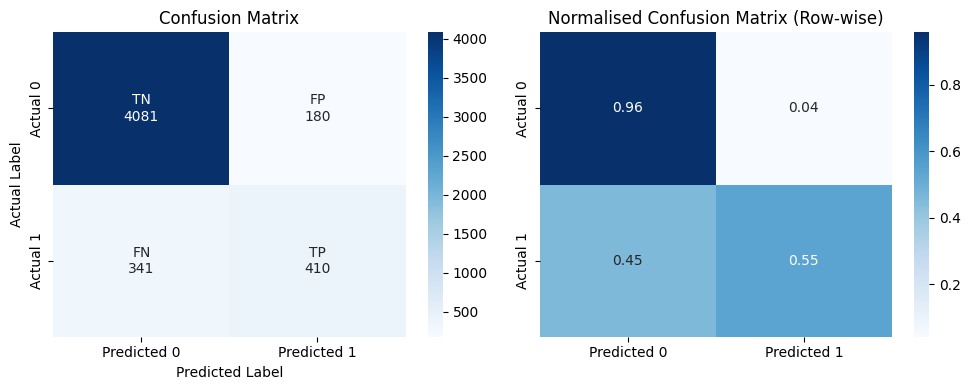

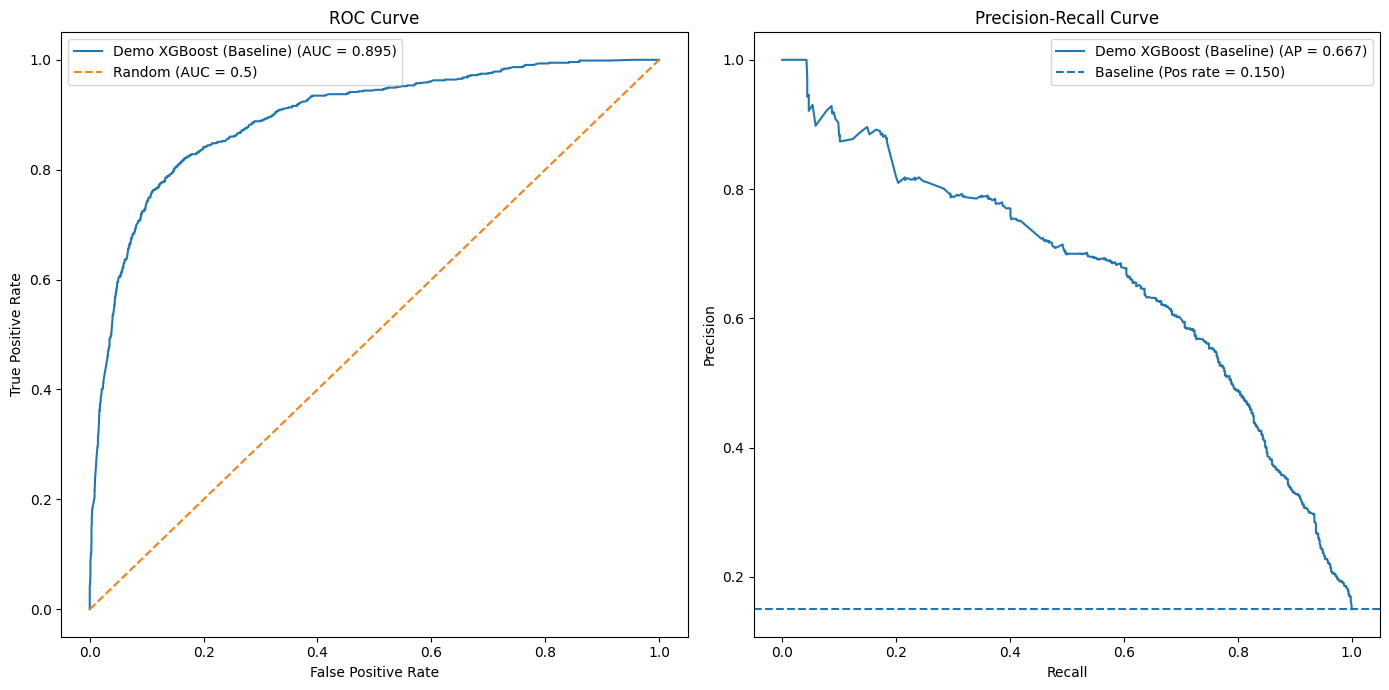

In [33]:
# declare the results dictionary here so it's in scope for the rest of the notebook, and we can see it being updated as we go along. 
results = {}
# select the number of jobs to use for XGBoost based on the system's capabilities, which can speed up training and tuning processes by utilizing multiple CPU cores.
# also limit it to max cores / 2 to avoid overloading the system, especially during tuning when multiple models are trained in parallel.
N_JOBS = choose_n_jobs()
xgb_model_path = DEMO_XGB_MODEL_DIR / 'demo_baseline.joblib'

xgb_params = {
    'n_estimators': 100,
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'eval_metric': 'auc',
    'n_jobs': N_JOBS,
}

xgb_was_loaded = False

if OVERWRITE_XGB_BASELINE:
    print('OVERWRITE_XGB_BASELINE=True: training a fresh XGBoost baseline model.')
    set_seed(SEED)
    # **xgb_params is used to unpack the dictionary of hyperparameters directly into the XGBClassifier constructor, allowing for a clean and flexible way to specify model parameters.
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    # save the trained model to disk using joblib, which allows for efficient serialization of Python objects, including machine learning models. 
    
    # The model is saved to the specified path for later use or analysis.
    joblib.dump(xgb_model, xgb_model_path)

elif LOAD_XGB_BASELINE:
    try:
        # Attempt to load the baseline XGBoost model from disk using joblib. 
        # If the model file exists and is compatible, it will be loaded into memory for use in predictions and evaluation.
        # model weights and parameters from the specified path, allowing for quick reuse of previously trained models without the need for retraining.
        xgb_model = joblib.load(xgb_model_path)
        xgb_was_loaded = True
        print(f'Loaded baseline XGBoost model from {xgb_model_path}')
    # If there is an error during loading (e.g., file not found, incompatible model), catch the exception and proceed to train a new model.
    except Exception as e:
        print(f'Could not load baseline XGBoost model from {xgb_model_path}: {e}')
        print('Training a fresh baseline XGBoost model and saving it.')
        set_seed(SEED)
        xgb_model = xgb.XGBClassifier(**xgb_params)
        xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        joblib.dump(xgb_model, xgb_model_path)
else:
    print('LOAD_XGB_BASELINE=False: training a fresh XGBoost baseline model.')
    set_seed(SEED)
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    joblib.dump(xgb_model, xgb_model_path)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

display(
    pd.Series(
        {
            'model_path': to_artifact_reference(xgb_model_path),
            'loaded_existing_model': xgb_was_loaded,
        }
    )
)

results = evaluate_and_store_model(
    results,
    m_id=1,
    model_name='Baseline',
    model_type='XGBoost',
    stage='Demo',
    y_true=y_test,
    y_pred=y_pred_xgb,
    y_prob=y_prob_xgb,
    hyperparameters=xgb_params,
    metadata={'threshold': 0.5, 'artifact_path': to_artifact_reference(xgb_model_path)},
)

print_model_metrics(results, 1)
plot_model_confusion_matrix(results, 1)
plot_roc_and_pr_curves(build_models_to_plot(results, [1]), figsize=(14, 7))


## B2. GridSearchCV Save / Load

This optional example stores a simple XGBoost `GridSearchCV` run under `demo_artifacts/tuning/gridsearch/`. It supports saved-result loading and explicit reruns, but it does not implement resume behaviour.


In [34]:
GRIDSEARCH_PARAM_GRID = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

gridsearch_best_params_path = DEMO_GRIDSEARCH_DIR / 'best_params.json'
gridsearch_cv_results_path = DEMO_GRIDSEARCH_DIR / 'cv_results.csv'
gridsearch_spec_path = DEMO_GRIDSEARCH_DIR / 'grid_spec.json'
gridsearch_estimator_path = DEMO_GRIDSEARCH_DIR / 'best_estimator.joblib'
gridsearch_required_paths = [
    gridsearch_best_params_path,
    gridsearch_cv_results_path,
    gridsearch_spec_path,
]

# The grid search either loads a saved summary or reruns the full search from scratch.
gridsearch_saved_results_available = all(path.exists() for path in gridsearch_required_paths)
gridsearch_best_params_payload = None
gridsearch_cv_results = pd.DataFrame()
gridsearch_best_estimator = None

if LOAD_SAVED_GRIDSEARCH and gridsearch_saved_results_available:
    with gridsearch_best_params_path.open('r', encoding='utf-8') as f:
        gridsearch_best_params_payload = json.load(f)
    gridsearch_cv_results = pd.read_csv(gridsearch_cv_results_path).sort_values('rank_test_score')
    if gridsearch_estimator_path.exists():
        gridsearch_best_estimator = joblib.load(gridsearch_estimator_path)
    print(f'Loaded saved GridSearchCV artefacts from {DEMO_GRIDSEARCH_DIR}')
elif RUN_GRIDSEARCH:
    print(f'Running GridSearchCV and refreshing artefacts in {DEMO_GRIDSEARCH_DIR}')
    demo_gridsearch = GridSearchCV(
        estimator=xgb.XGBClassifier(
            n_estimators=100,
            objective='binary:logistic',
            eval_metric='auc',
            random_state=SEED,
            n_jobs=N_JOBS,
            tree_method='hist',
        ),
        param_grid=GRIDSEARCH_PARAM_GRID,
        scoring='roc_auc',
        cv=3,
        n_jobs=N_JOBS,
        refit=True,
        verbose=1,
    )
    demo_gridsearch.fit(X_train, y_train)
    gridsearch_best_estimator = demo_gridsearch.best_estimator_
    gridsearch_best_params_payload = {
        'best_score': float(demo_gridsearch.best_score_),
        'best_params': demo_gridsearch.best_params_,
    }
    gridsearch_cv_results = pd.DataFrame(demo_gridsearch.cv_results_).sort_values('rank_test_score')
    save_json(gridsearch_best_params_path, gridsearch_best_params_payload)
    save_json(
        gridsearch_spec_path,
        {
            'estimator': 'xgboost.XGBClassifier',
            'param_grid': GRIDSEARCH_PARAM_GRID,
            'scoring': 'roc_auc',
            'cv': 3,
            'refit': True,
        },
    )
    gridsearch_cv_results.to_csv(gridsearch_cv_results_path, index=False)
    joblib.dump(gridsearch_best_estimator, gridsearch_estimator_path)
else:
    print(
        f'No saved GridSearchCV artefacts were found in {DEMO_GRIDSEARCH_DIR}. '
        'RUN_GRIDSEARCH is False, so GridSearchCV was skipped.'
    )

if gridsearch_best_params_payload is not None:
    display(
        pd.Series(
            {
                'best_params_path': to_artifact_reference(gridsearch_best_params_path),
                'cv_results_path': to_artifact_reference(gridsearch_cv_results_path),
                'grid_spec_path': to_artifact_reference(gridsearch_spec_path),
                'best_estimator_path': to_artifact_reference(gridsearch_estimator_path) if gridsearch_estimator_path.exists() else 'not_saved',
                'best_score': gridsearch_best_params_payload.get('best_score'),
                'best_params': gridsearch_best_params_payload.get('best_params'),
            }
        )
    )
    display(gridsearch_cv_results.head())


Loaded saved GridSearchCV artefacts from /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/tuning/gridsearch


best_params_path       demo_artifacts/tuning/gridsearch/best_params.json
cv_results_path          demo_artifacts/tuning/gridsearch/cv_results.csv
grid_spec_path           demo_artifacts/tuning/gridsearch/grid_spec.json
best_estimator_path    demo_artifacts/tuning/gridsearch/best_estimato...
best_score                                                      0.895981
best_params            {'colsample_bytree': 1.0, 'learning_rate': 0.1...
dtype: object

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.230029,0.002100,0.020826,0.001547,1.0,0.10,5,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.902178,0.893417,0.892348,0.895981,0.004403,1
1,0.314259,0.004002,0.038516,0.007362,0.8,0.10,5,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.902312,0.891769,0.892181,0.895421,0.004876,2
2,0.321006,0.012881,0.025988,0.001524,0.8,0.10,5,1.0,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.899779,0.891333,0.889828,0.893647,0.004380,3
3,0.202699,0.009787,0.019320,0.002810,1.0,0.10,5,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.898641,0.891727,0.888871,0.893080,0.004102,4
4,0.334863,0.008793,0.030991,0.002317,1.0,0.05,5,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.897713,0.890124,0.890188,0.892675,0.003563,5


## C. Baseline Neural Network Save / Load

This section uses the neural-network baseline flags to decide whether to load a saved `.keras` model or train a fresh one.

Loaded baseline neural-network model from /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/models/neural_network/demo_baseline.keras


model_path                  demo_artifacts/models/neural_network/demo_base...
history_path                demo_artifacts/models/neural_network/demo_base...
loaded_existing_model                                                    True
predictions_close_enough                                                 True
max_abs_diff                                                              0.0
dtype: object

Demo Neural Network - Baseline Performance Metrics:
Accuracy:    0.8947
Precision:   0.6718
Recall:      0.5806
Specificity: 0.9500
AUC:         0.8911


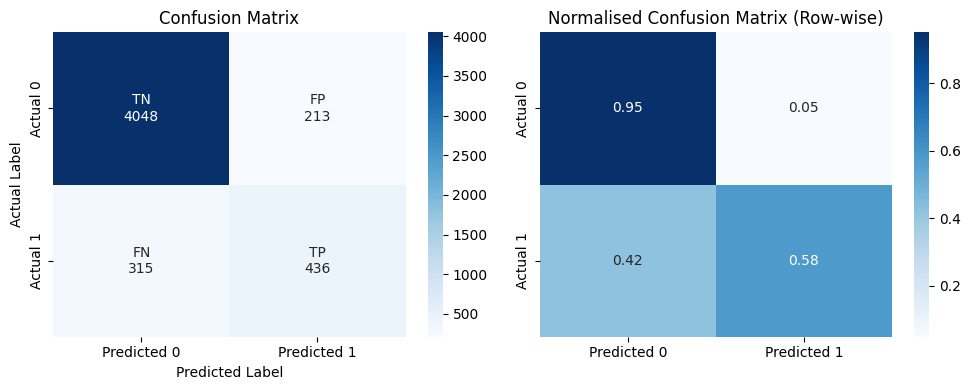

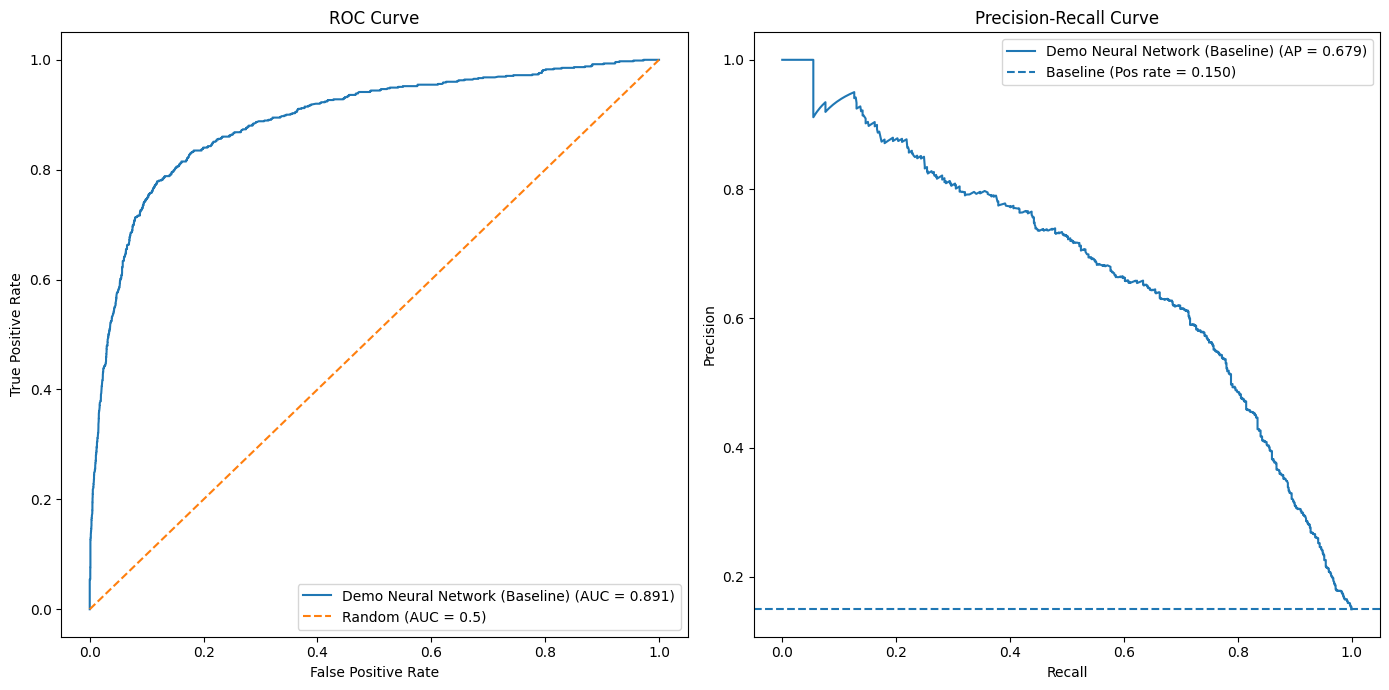

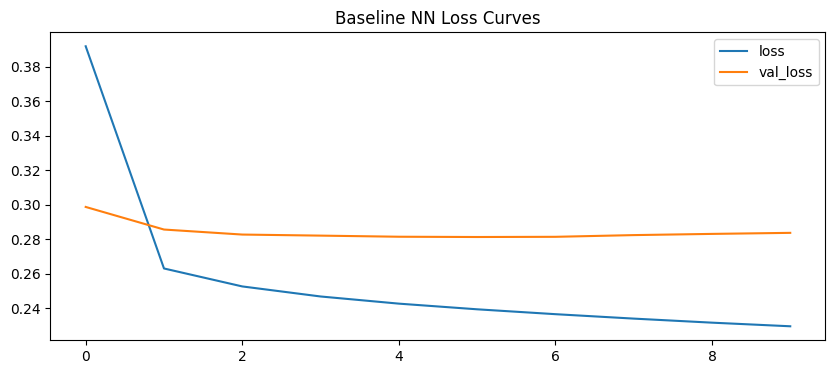

In [35]:
tf.keras.backend.clear_session()
set_seed(SEED)

baseline_nn_model_path = DEMO_NN_MODEL_DIR / 'demo_baseline.keras'
baseline_nn_history_path = DEMO_NN_MODEL_DIR / 'demo_baseline_history.h5'

baseline_nn_params = {
    'epochs': BASELINE_NN_EPOCHS,
    'batch_size': BASELINE_NN_BATCH_SIZE,
    'units': 32,
    'layers': 1,
    'dropout': 0.0,
    'l2_strength': 0.0,
    'lr': 1e-3,
    'optimizer': 'adam',
    'activation': 'relu',
}

baseline_nn_history = None
nn_was_loaded = False


if OVERWRITE_NN_BASELINE:
    print('OVERWRITE_NN_BASELINE=True: training a fresh baseline neural-network model.')
    # build_binary_classifier is a helper function that constructs a neural network model based on the specified hyperparameters, 
    # including the number of layers, units per layer, dropout rate, L2 regularization strength, learning rate, optimizer type, and activation function.
    baseline_nn = build_binary_classifier(
        input_dim=X_train_s.shape[1],
        units=baseline_nn_params['units'],
        layers=baseline_nn_params['layers'],
        dropout=baseline_nn_params['dropout'],
        l2_strength=baseline_nn_params['l2_strength'],
        lr=baseline_nn_params['lr'],
        optimizer=baseline_nn_params['optimizer'],
        activation=baseline_nn_params['activation'],
    )
else:
    baseline_nn = None

# Attempt to load the baseline neural-network model from disk if LOAD_NN_BASELINE is True and a model was not already created due to OVERWRITE_NN_BASELINE.
if baseline_nn is None and LOAD_NN_BASELINE:
    try:
        # Attempt to load the baseline neural-network model from disk using Keras's load_model function.
        # If the model file exists and is compatible, it will be loaded into memory for use in predictions and evaluation.
        # This allows for quick reuse of previously trained models without the need for retraining
        baseline_nn = load_model(baseline_nn_model_path)
        nn_was_loaded = True
        print(f'Loaded baseline neural-network model from {baseline_nn_model_path}')
        if baseline_nn_history_path.exists():
            baseline_nn_history = pd.read_hdf(baseline_nn_history_path, key='history')
    except Exception as e:
        print(f'Could not load baseline neural-network model from {baseline_nn_model_path}: {e}')
        print('Training a fresh baseline neural-network model and saving it.')
        baseline_nn = build_binary_classifier(
            input_dim=X_train_s.shape[1],
            units=baseline_nn_params['units'],
            layers=baseline_nn_params['layers'],
            dropout=baseline_nn_params['dropout'],
            l2_strength=baseline_nn_params['l2_strength'],
            lr=baseline_nn_params['lr'],
            optimizer=baseline_nn_params['optimizer'],
            activation=baseline_nn_params['activation'],
        )

# If the baseline neural-network model was not loaded from disk (either because it doesn't exist or because loading failed),
#  we proceed to train a new model using the specified hyperparameters and training data. After training, the model is saved to disk for future use.
if baseline_nn is None:
    print('LOAD_NN_BASELINE=False: training a fresh baseline neural-network model.')
    baseline_nn = build_binary_classifier(
        input_dim=X_train_s.shape[1],
        units=baseline_nn_params['units'],
        layers=baseline_nn_params['layers'],
        dropout=baseline_nn_params['dropout'],
        l2_strength=baseline_nn_params['l2_strength'],
        lr=baseline_nn_params['lr'],
        optimizer=baseline_nn_params['optimizer'],
        activation=baseline_nn_params['activation'],
    )

# If the model was not loaded, we train it and save both the model and its training history. We use early stopping based on validation AUC to prevent overfitting, and we restore the best weights after training.
if not nn_was_loaded:
    baseline_early_stop = KerasEarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=3,
        restore_best_weights=True,
        min_delta=1e-4,
    )

    baseline_history_obj = baseline_nn.fit(
        X_train_s,
        y_train,
        validation_data=(X_val_s, y_val),
        epochs=baseline_nn_params['epochs'],
        batch_size=baseline_nn_params['batch_size'],
        shuffle=False,
        verbose=0,
        callbacks=[baseline_early_stop],
    )
    # save the trained model to disk using Keras's save function, which allows for efficient serialization of the model architecture, weights, and training configuration.
    baseline_nn.save(baseline_nn_model_path)
    # save the training history to disk in HDF5 format using pandas, which allows for efficient storage and retrieval of large datasets. 
    # The history is saved separately from the model because Keras's save_model does not include the training history, and we want to be able to access it even if the model was loaded from disk.
    pd.DataFrame(baseline_history_obj.history).to_hdf(baseline_nn_history_path, key='history', mode='w')
    baseline_nn_history = pd.DataFrame(baseline_history_obj.history)

# If the model was loaded successfully, we attempt to load the training history from disk as well, 
# which allows us to analyze the training process and visualize metrics such as loss curves.
# this is stored separately from the model because Keras's save_model does not include the training history, and we want to be able to access it even if the model was loaded from disk.
if baseline_nn_history is None and baseline_nn_history_path.exists():
    baseline_nn_history = pd.read_hdf(baseline_nn_history_path, key='history')

# Reload once more to confirm the saved model can be read back cleanly.
baseline_nn_reloaded = load_model(baseline_nn_model_path)

y_prob_nn = baseline_nn.predict(X_test_s, verbose=0).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)
y_prob_nn_reloaded = baseline_nn_reloaded.predict(X_test_s, verbose=0).ravel()

display(
    pd.Series(
        {
            'model_path': to_artifact_reference(baseline_nn_model_path),
            'history_path': to_artifact_reference(baseline_nn_history_path),
            'loaded_existing_model': nn_was_loaded,
            'predictions_close_enough': bool(np.allclose(y_prob_nn, y_prob_nn_reloaded, atol=1e-6)),
            'max_abs_diff': float(np.max(np.abs(y_prob_nn - y_prob_nn_reloaded))),
        }
    )
)

results = evaluate_and_store_model(
    results,
    m_id=2,
    model_name='Baseline',
    model_type='Neural Network',
    stage='Demo',
    y_true=y_test,
    y_pred=y_pred_nn,
    y_prob=y_prob_nn,
    hyperparameters=baseline_nn_params,
    metadata={'threshold': 0.5, 'history_rows': 0 if baseline_nn_history is None else len(baseline_nn_history)},
)

print_model_metrics(results, 2)
plot_model_confusion_matrix(results, 2)
plot_roc_and_pr_curves(build_models_to_plot(results, [2]), figsize=(14, 7))

if baseline_nn_history is not None:
    baseline_nn_history[['loss', 'val_loss']].plot(figsize=(10, 4), title='Baseline NN Loss Curves');
    plt.show()


## D. XGBoost Tuning Save / Load / Overwrite

This section demonstrates Optuna persistence under `demo_artifacts/tuning/xgboost/` and saves the tuned XGBoost model under `demo_artifacts/models/xgboost/`.

In [36]:
XGB_SEARCH_SPACE = {
    'learning_rate': {'low': 0.03, 'high': 0.2, 'log': True},
    'max_depth': {'low': 3, 'high': 5},
    'min_child_weight': {'low': 1.0, 'high': 5.0, 'log': True},
    'gamma': {'low': 0.0, 'high': 1.0},
    'subsample': {'low': 0.7, 'high': 1.0},
    'colsample_bytree': {'low': 0.7, 'high': 1.0},
    'reg_alpha': {'low': 1e-8, 'high': 1e-1, 'log': True},
    'reg_lambda': {'low': 1e-3, 'high': 10.0, 'log': True},
}

# Keep the Optuna setup visible in the notebook so the save/load/resume flow is easy to explain.
xgb_tuned_model = None
xgb_tuned_params = None
xgb_tuned_loaded = False
xgb_tuned_val_auc = None
xgb_study = None
xgb_study_name = 'demo_xgb_search'
xgb_saved_study_path = DEMO_XGB_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['optuna_study']
xgb_best_params_path = DEMO_XGB_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['best_params']
xgb_trials_path = DEMO_XGB_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['trials']
xgb_model_path = DEMO_XGB_MODEL_DIR / TUNING_ARTIFACT_FILENAMES['best_model_joblib']
xgb_storage_url = f"sqlite:///{xgb_saved_study_path}"
xgb_saved_artifacts_available = xgb_saved_study_path.exists()

def count_xgb_completed_trials(study):
    return sum(1 for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE)

def suggest_xgb_params(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', XGB_SEARCH_SPACE['learning_rate']['low'], XGB_SEARCH_SPACE['learning_rate']['high'], log=XGB_SEARCH_SPACE['learning_rate']['log']),
        'max_depth': trial.suggest_int('max_depth', XGB_SEARCH_SPACE['max_depth']['low'], XGB_SEARCH_SPACE['max_depth']['high']),
        'min_child_weight': trial.suggest_float('min_child_weight', XGB_SEARCH_SPACE['min_child_weight']['low'], XGB_SEARCH_SPACE['min_child_weight']['high'], log=XGB_SEARCH_SPACE['min_child_weight']['log']),
        'gamma': trial.suggest_float('gamma', XGB_SEARCH_SPACE['gamma']['low'], XGB_SEARCH_SPACE['gamma']['high']),
        'subsample': trial.suggest_float('subsample', XGB_SEARCH_SPACE['subsample']['low'], XGB_SEARCH_SPACE['subsample']['high']),
        'colsample_bytree': trial.suggest_float('colsample_bytree', XGB_SEARCH_SPACE['colsample_bytree']['low'], XGB_SEARCH_SPACE['colsample_bytree']['high']),
        'reg_alpha': trial.suggest_float('reg_alpha', XGB_SEARCH_SPACE['reg_alpha']['low'], XGB_SEARCH_SPACE['reg_alpha']['high'], log=XGB_SEARCH_SPACE['reg_alpha']['log']),
        'reg_lambda': trial.suggest_float('reg_lambda', XGB_SEARCH_SPACE['reg_lambda']['low'], XGB_SEARCH_SPACE['reg_lambda']['high'], log=XGB_SEARCH_SPACE['reg_lambda']['log']),
    }

def build_xgb_callbacks(rounds):
    return [XgbEarlyStopping(rounds=rounds, metric_name='auc', maximize=True)]

# The xgb_objective function defines the objective for the Optuna optimization process. 
# It takes a trial object as input, which is used to suggest hyperparameters for the XGBoost model. 
# The function trains an XGBoost classifier with the suggested hyperparameters on the training data and evaluates its performance on the validation set using the AUC metric. 
# The best iteration is determined based on early stopping, and the predicted probabilities for the validation set are obtained accordingly. 
# Finally, the function returns the AUC score, which Optuna will use to guide the optimization process.
def xgb_objective(trial):
    model = xgb.XGBClassifier(
        n_estimators=XGB_TUNING_N_ESTIMATORS,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=SEED,
        n_jobs=N_JOBS,
        tree_method='hist',
        callbacks=build_xgb_callbacks(20),
        **suggest_xgb_params(trial),
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    best_iter = getattr(model, 'best_iteration', None)
    if best_iter is not None:
        y_val_prob = model.predict_proba(X_val, iteration_range=(0, best_iter + 1))[:, 1]
    else:
        y_val_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_val_prob)

# OVERWRITE removes the old study before we recreate or reload it.
if OVERWRITE_XGB_TUNING and xgb_saved_study_path.exists():
    try:
        optuna.delete_study(study_name=xgb_study_name, storage=xgb_storage_url)
    except KeyError:
        pass

# Create or load the Optuna study for XGBoost tuning. The study is configured to maximize the AUC metric, and it uses a TPE sampler with a fixed random seed for reproducibility.
xgb_study = optuna.create_study(
    study_name=xgb_study_name,
    direction='maximize',
    storage=xgb_storage_url,
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
# Count the number of completed trials in the study to determine whether tuning needs to be run or can be skipped based on existing results and the specified tuning policy.
xgb_completed_trials = count_xgb_completed_trials(xgb_study)

if OVERWRITE_XGB_TUNING:
    print('OVERWRITE_XGB_TUNING=True: running a fresh Optuna XGBoost search.')
    xgb_study.optimize(xgb_objective, n_trials=XGB_N_TRIALS, show_progress_bar=True)
elif RUN_XGB_TUNING:
    if xgb_completed_trials >= XGB_N_TRIALS:
        print(
            'Skipping XGBoost tuning rerun because '
            f'{xgb_completed_trials} completed trials already exist in {DEMO_XGB_TUNING_DIR} '
            f'(requested total: {XGB_N_TRIALS}).'
        )
        xgb_tuned_loaded = xgb_completed_trials > 0
    elif xgb_completed_trials > 0 and RESUME_XGB_TUNING:
        remaining_trials = XGB_N_TRIALS - xgb_completed_trials
        print(
            'Resuming XGBoost tuning from '
            f'{DEMO_XGB_TUNING_DIR} with {xgb_completed_trials} completed trials. '
            f'Running {remaining_trials} additional trials.'
        )
        xgb_tuned_loaded = True
        xgb_study.optimize(xgb_objective, n_trials=remaining_trials, show_progress_bar=True)
    elif xgb_completed_trials > 0 and not RESUME_XGB_TUNING:
        print(
            'Saved XGBoost tuning artefacts already exist in '
            f'{DEMO_XGB_TUNING_DIR} with {xgb_completed_trials} completed trials. '
            'Resume is disabled, so no additional trials will run.'
        )
        xgb_tuned_loaded = True
    else:
        print(
            'Starting a new XGBoost tuning run in '
            f'{DEMO_XGB_TUNING_DIR} for {XGB_N_TRIALS} trials.'
        )
        xgb_study.optimize(xgb_objective, n_trials=XGB_N_TRIALS, show_progress_bar=True)
else:
    if LOAD_SAVED_TUNING and xgb_completed_trials > 0:
        print(
            'Loading saved XGBoost tuning results from '
            f'{DEMO_XGB_TUNING_DIR} without rerunning tuning.'
        )
        xgb_tuned_loaded = True
    else:
        print(
            f'No saved XGBoost tuning artefacts found in {DEMO_XGB_TUNING_DIR}. '
            'RUN_XGB_TUNING is disabled, so tuning was skipped.'
        )

xgb_completed_trials = count_xgb_completed_trials(xgb_study)
if xgb_completed_trials > 0:
    xgb_tuned_params = xgb_study.best_params
    xgb_tuned_val_auc = xgb_study.best_value
    xgb_tuned_model = xgb.XGBClassifier(
        n_estimators=XGB_TUNING_N_ESTIMATORS,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=SEED,
        n_jobs=N_JOBS,
        tree_method='hist',
        callbacks=build_xgb_callbacks(20),
        **xgb_tuned_params,
    )
    xgb_tuned_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    # Save the refreshed tuning summary and the retrained best model.
    save_json(xgb_best_params_path, {'best_val_auc': float(xgb_tuned_val_auc), 'best_params': xgb_tuned_params})
    # save the best model found during tuning to disk using joblib, which allows for efficient serialization of Python objects, including machine learning models.
    joblib.dump(xgb_tuned_model, xgb_model_path)
    xgb_study.trials_dataframe().to_csv(xgb_trials_path, index=False)

xgb_tuning_summary = pd.Series(
    {
        'best_params_path': to_artifact_reference(DEMO_XGB_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['best_params']),
        'trials_path': to_artifact_reference(DEMO_XGB_TUNING_DIR / TUNING_ARTIFACT_FILENAMES['trials']),
        'study_path': to_artifact_reference(xgb_saved_study_path),
        'model_path': to_artifact_reference(DEMO_XGB_MODEL_DIR / TUNING_ARTIFACT_FILENAMES['best_model_joblib']),
        'saved_study_found_at_start': xgb_saved_artifacts_available,
        'loaded_existing_tuning': xgb_tuned_loaded,
        'requested_total_trials': XGB_N_TRIALS,
        'completed_trials': 0 if xgb_study is None else sum(1 for trial in xgb_study.trials if trial.state == optuna.trial.TrialState.COMPLETE),
        'best_val_auc': xgb_tuned_val_auc,
    }
)
display(xgb_tuning_summary)

if xgb_tuned_model is None or xgb_tuned_params is None:
    print('XGBoost tuning was skipped because saved artefacts were not found and RUN_XGB_TUNING is False.')
else:
    y_prob_xgb_tuned = xgb_tuned_model.predict_proba(X_test)[:, 1]
    y_pred_xgb_tuned = (y_prob_xgb_tuned >= 0.5).astype(int)

    results = evaluate_and_store_model(
        results,
        m_id=3,
        model_name='Tuned',
        model_type='XGBoost',
        stage='Demo',
        y_true=y_test,
        y_pred=y_pred_xgb_tuned,
        y_prob=y_prob_xgb_tuned,
        hyperparameters=xgb_tuned_params,
        metadata={'threshold': 0.5, 'loaded_existing_tuning': xgb_tuned_loaded},
    )

    print_model_metrics(results, 3)
    plot_model_confusion_matrix(results, 3)
    plot_roc_and_pr_curves(build_models_to_plot(results, [3]), figsize=(14, 7))


[I 2026-03-26 19:40:06,920] Using an existing study with name 'demo_xgb_search' instead of creating a new one.


No saved XGBoost tuning artefacts found in /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/tuning/xgboost. RUN_XGB_TUNING is disabled, so tuning was skipped.


best_params_path                 demo_artifacts/tuning/xgboost/best_params.json
trials_path                            demo_artifacts/tuning/xgboost/trials.csv
study_path                    demo_artifacts/tuning/xgboost/optuna_study.sql...
model_path                      demo_artifacts/models/xgboost/best_model.joblib
saved_study_found_at_start                                                 True
loaded_existing_tuning                                                    False
requested_total_trials                                                       10
completed_trials                                                              0
best_val_auc                                                               None
dtype: object

XGBoost tuning was skipped because saved artefacts were not found and RUN_XGB_TUNING is False.


## E. Neural-Network Tuning Save / Load / Overwrite

This section demonstrates Keras Tuner save/load/resume/overwrite behaviour under `demo_artifacts/tuning/keras_tuner/`.

Reloading Tuner from /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/tuning/keras_tuner/demo_nn_search/tuner0.json
Skipping neural-network tuning rerun because 5 completed trials already exist in /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/tuning/keras_tuner/demo_nn_search (requested total: 5).


/home/alextd/venvs/tf-gpu311/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


best_params_path              demo_artifacts/tuning/keras_tuner/demo_best_pa...
trials_path                   demo_artifacts/tuning/keras_tuner/demo_trials.csv
search_summary_path           demo_artifacts/tuning/keras_tuner/demo_search_...
best_model_path               demo_artifacts/models/neural_network/demo_best...
oracle_path                   demo_artifacts/tuning/keras_tuner/demo_nn_sear...
saved_tuner_found_at_start                                                 True
loaded_existing_tuning                                                     True
requested_total_trials                                                        5
completed_trials                                                              5
dtype: object

/home/alextd/venvs/tf-gpu311/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters: {'units': 48, 'layers': 1, 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'dropout': 0.1, 'l2_strength': 1e-05}
Demo Neural Network - Tuned Performance Metrics:
Accuracy:    0.8907
Precision:   0.6747
Recall:      0.5220
Specificity: 0.9556
AUC:         0.8792


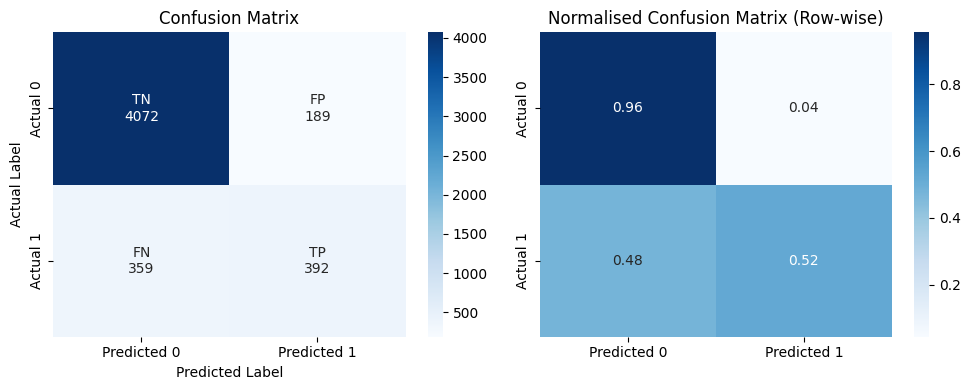

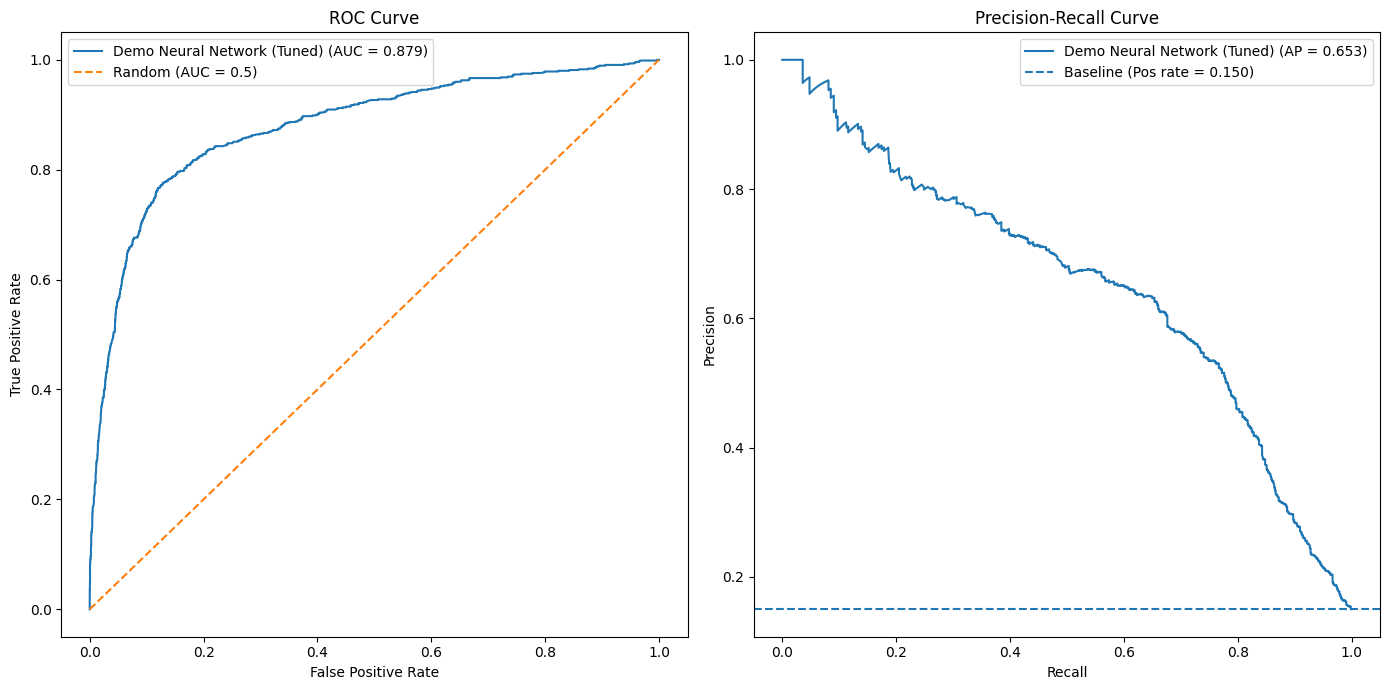

In [37]:
NN_SEARCH_SPACE = {
    'units': {'min_value': 16, 'max_value': 48, 'step': 16},
    'layers': {'min_value': 1, 'max_value': 2},
    'dropout': {'min_value': 0.0, 'max_value': 0.2, 'step': 0.1},
    'activation': ['relu'],
    'optimizer': ['adam'],
    'lr': [1e-3, 3e-4],
    'l2_strength': [0.0, 1e-5],
}

def run_demo_keras_tuner(run_search, load_saved, overwrite, resume_search):
    def count_completed_trials(tuner):
        # This function counts the number of completed trials in the Keras Tuner's oracle, which is necessary because Keras Tuner does not provide a built-in method to easily check the number of completed trials.
        return sum(
            1
            for trial in tuner.oracle.trials.values()
            if str(trial.status).split('.')[-1].upper() == 'COMPLETED'
        )

    def build_model_for_tuner(hp):
        return build_binary_classifier(
            input_dim=X_train_tuner.shape[1],
            units=hp.Int('units', **NN_SEARCH_SPACE['units']),
            layers=hp.Int('layers', **NN_SEARCH_SPACE['layers']),
            activation=hp.Choice('activation', NN_SEARCH_SPACE['activation']),
            optimizer=hp.Choice('optimizer', NN_SEARCH_SPACE['optimizer']),
            lr=hp.Choice('lr', NN_SEARCH_SPACE['lr']),
            dropout=hp.Float('dropout', **NN_SEARCH_SPACE['dropout']),
            l2_strength=hp.Choice('l2_strength', NN_SEARCH_SPACE['l2_strength']),
        )

    tuner_project_name = 'demo_nn_search'
    tuner_project_dir = DEMO_KERAS_TUNER_DIR / tuner_project_name
    oracle_path = tuner_project_dir / 'oracle.json'
    trials_path = DEMO_KERAS_TUNER_DIR / 'demo_trials.csv'
    best_params_path = DEMO_KERAS_TUNER_DIR / 'demo_best_params.json'
    best_model_path = DEMO_NN_MODEL_DIR / 'demo_best_model_training.keras'
    search_summary_path = DEMO_KERAS_TUNER_DIR / 'demo_search_summary.txt'

    early_stop = KerasEarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=3,
        restore_best_weights=True,
        min_delta=1e-4,
    )

    # Initialize the Keras Tuner RandomSearch tuner with the specified search space, objective, and directory for saving artifacts. 
    # The tuner will manage the hyperparameter search process, including saving trial results and allowing for resumption of searches.
    # number of trials is set to NN_N_TRIALS, and the random seed is provided for reproducibility. 
    # The overwrite flag controls whether existing tuner artifacts should be overwritten or preserved.
    tuner = kt.RandomSearch(
        build_model_for_tuner,
        objective=kt.Objective('val_auc', direction='max'),
        max_trials=NN_N_TRIALS,
        directory=os.fspath(DEMO_KERAS_TUNER_DIR),
        project_name=tuner_project_name,
        overwrite=overwrite,
        seed=SEED,
    )

    # If load_saved is True and overwrite is False, attempt to reload the tuner state from the oracle path.
    if load_saved and not overwrite and oracle_path.exists():
        tuner.reload()
        if hasattr(tuner.oracle, 'max_trials'):
            tuner.oracle.max_trials = max(tuner.oracle.max_trials, NN_N_TRIALS)
        if hasattr(tuner, 'max_trials'):
            tuner.max_trials = max(tuner.max_trials, NN_N_TRIALS)

    saved_exists = oracle_path.exists()
    completed_trials = count_completed_trials(tuner)
    loaded_existing = saved_exists and completed_trials > 0

    # The tuner either reloads saved trial state, resumes the remaining trials, or starts a fresh search.
    if run_search:
        if completed_trials >= NN_N_TRIALS:
            print(
                'Skipping neural-network tuning rerun because '
                f'{completed_trials} completed trials already exist in {tuner_project_dir} '
                f'(requested total: {NN_N_TRIALS}).'
            )
        elif completed_trials > 0 and resume_search:
            print(
                'Resuming neural-network tuning from '
                f'{tuner_project_dir} with {completed_trials} completed trials. '
                f'Running until {NN_N_TRIALS} total trials are reached.'
            )
            # The tuner will continue the search process from the existing state, allowing it to pick up where it left off without losing previously completed trials.
            tuner.search(
                X_train_tuner,
                y_train_tuner,
                validation_data=(X_val_tuner, y_val_tuner),
                epochs=15,
                batch_size=NN_TUNER_BATCH_SIZE,
                callbacks=[early_stop],
                verbose=1,
            )
        elif completed_trials > 0 and not resume_search:
            print(
                'Saved neural-network tuning artefacts already exist in '
                f'{tuner_project_dir} with {completed_trials} completed trials. '
                'Resume is disabled, so no additional trials will run.'
            )
        else:
            print(
                'Starting a new neural-network tuning run in '
                f'{tuner_project_dir} for up to {NN_N_TRIALS} trials.'
            )
            tuner.search(
                X_train_tuner,
                y_train_tuner,
                validation_data=(X_val_tuner, y_val_tuner),
                epochs=15,
                batch_size=NN_TUNER_BATCH_SIZE,
                callbacks=[early_stop],
                verbose=1,
            )
    elif load_saved and saved_exists:
        print(
            'Loading saved neural-network tuning results from '
            f'{tuner_project_dir} without rerunning tuning.'
        )
    else:
        print(
            f'No saved neural-network tuning artefacts found at {tuner_project_dir}. '
            'RUN_NN_TUNING is disabled, so tuning was skipped.'
        )
        return None

    if not tuner.oracle.trials:
        print(
            f'No neural-network tuning trials are available in {tuner_project_dir}. '
            'Set RUN_NN_TUNING = True to generate them.'
        )
        return None

    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.get_best_models(1)[0]
    best_model.save(best_model_path)

    # Save a compact tabular summary so the search can be inspected without rerunning it.
    trials_df = tuner_trials_to_dataframe(tuner)
    if not trials_df.empty:
        trials_df.to_csv(trials_path, index=False)

    summary_buffer = io.StringIO()
    with contextlib.redirect_stdout(summary_buffer):
        tuner.results_summary()
    search_summary_path.write_text(summary_buffer.getvalue(), encoding='utf-8')

    save_json(best_params_path, {'project_name': tuner_project_name, 'best_params': best_hp.values})

    return {
        'tuner': tuner,
        'best_hp': best_hp,
        'completed_trials': count_completed_trials(tuner),
        'loaded_existing': loaded_existing,
        'oracle_path': oracle_path,
        'trials_path': trials_path,
        'best_params_path': best_params_path,
        'best_model_path': best_model_path,
        'search_summary_path': search_summary_path,
    }

nn_tuning_loaded = False
nn_tuning_result = None
nn_tuner_project_dir = DEMO_KERAS_TUNER_DIR / 'demo_nn_search'
nn_saved_artifacts_available = (nn_tuner_project_dir / 'oracle.json').exists()

try:
    if OVERWRITE_NN_TUNING:
        print('OVERWRITE_NN_TUNING=True: running a fresh Keras Tuner search.')
        nn_tuning_result = run_demo_keras_tuner(
            run_search=True,
            load_saved=False,
            overwrite=True,
            resume_search=False,
        )
    else:
        nn_tuning_result = run_demo_keras_tuner(
            run_search=RUN_NN_TUNING,
            load_saved=LOAD_SAVED_TUNING,
            overwrite=False,
            resume_search=RESUME_NN_TUNING,
        )
        nn_tuning_loaded = bool(nn_tuning_result and nn_tuning_result['loaded_existing'])
except Exception as e:
    print(f'Could not load or reuse saved neural-network tuning artefacts: {e}')
    print('Starting a fresh Keras Tuner search and saving new artefacts.')
    nn_tuning_result = run_demo_keras_tuner(
        run_search=True,
        load_saved=False,
        overwrite=False,
        resume_search=RESUME_NN_TUNING,
    )

nn_tuning_summary = pd.Series(
    {
        'best_params_path': to_artifact_reference(DEMO_KERAS_TUNER_DIR / 'demo_best_params.json'),
        'trials_path': to_artifact_reference(DEMO_KERAS_TUNER_DIR / 'demo_trials.csv'),
        'search_summary_path': to_artifact_reference(DEMO_KERAS_TUNER_DIR / 'demo_search_summary.txt'),
        'best_model_path': to_artifact_reference(DEMO_NN_MODEL_DIR / 'demo_best_model_training.keras'),
        'oracle_path': to_artifact_reference(nn_tuner_project_dir / 'oracle.json'),
        'saved_tuner_found_at_start': nn_saved_artifacts_available,
        'loaded_existing_tuning': nn_tuning_loaded,
        'requested_total_trials': NN_N_TRIALS,
        'completed_trials': None if nn_tuning_result is None else nn_tuning_result['completed_trials'],
    }
)
display(nn_tuning_summary)

if nn_tuning_result is None:
    print('Neural-network tuning was skipped because saved artefacts were not found and RUN_NN_TUNING is False.')
else:
    tuner_best_model = load_model(nn_tuning_result['best_model_path'])
    y_prob_tuner = tuner_best_model.predict(X_test_s, verbose=0).ravel()
    y_pred_tuner = (y_prob_tuner >= 0.5).astype(int)

    results = evaluate_and_store_model(
        results,
        m_id=4,
        model_name='Tuned',
        model_type='Neural Network',
        stage='Demo',
        y_true=y_test,
        y_pred=y_pred_tuner,
        y_prob=y_prob_tuner,
        hyperparameters=nn_tuning_result['best_hp'].values,
        metadata={'threshold': 0.5, 'loaded_existing_tuning': nn_tuning_loaded},
    )

    print('Best hyperparameters:', nn_tuning_result['best_hp'].values)
    print_model_metrics(results, 4)
    plot_model_confusion_matrix(results, 4)
    plot_roc_and_pr_curves(build_models_to_plot(results, [4]), figsize=(14, 7))


## F. Manual Neural-Network Grid Search

The manual grid-search artefacts reuse the notebook's neural-network tuning flags. Histories are stored in a dedicated subfolder so the saved results remain easy to inspect during a demo.


Loaded saved manual neural-network grid-search artefacts from /home/alextd/projects/ml-model-persistence-demo/demo_artifacts/tuning/nn_grid_search.


config_idx,units,layers,activation,optimizer,lr,dropout,l2_strength,epochs_ran,val_auc,test_auc,model_path,history_path
2,32,1,relu,adam,0.0010,0.1,0.00000,8,0.864975,0.880213,demo_artifacts/tuning/nn_grid_search/models/demo_tuned_model_config_2.keras,demo_artifacts/tuning/nn_grid_search/histories/demo_tuned_model_config_2_history.h5
1,16,1,relu,adam,0.0010,0.0,0.00000,8,0.851296,0.877231,demo_artifacts/tuning/nn_grid_search/models/demo_tuned_model_config_1.keras,demo_artifacts/tuning/nn_grid_search/histories/demo_tuned_model_config_1_history.h5
3,48,2,relu,adam,0.0003,0.1,0.00001,3,0.844535,0.802651,demo_artifacts/tuning/nn_grid_search/models/demo_tuned_model_config_3.keras,demo_artifacts/tuning/nn_grid_search/histories/demo_tuned_model_config_3_history.h5


results_csv_path          demo_artifacts/tuning/nn_grid_search/demo_manu...
results_json_path         demo_artifacts/tuning/nn_grid_search/demo_manu...
best_params_path          demo_artifacts/tuning/nn_grid_search/demo_best...
best_model_path           demo_artifacts/tuning/nn_grid_search/models/de...
best_history_path         demo_artifacts/tuning/nn_grid_search/histories...
loaded_existing_tuning                                                 True
dtype: object

Demo Neural Network - Manual Grid Best Performance Metrics:
Accuracy:    0.8921
Precision:   0.6610
Recall:      0.5739
Specificity: 0.9481
AUC:         0.8802


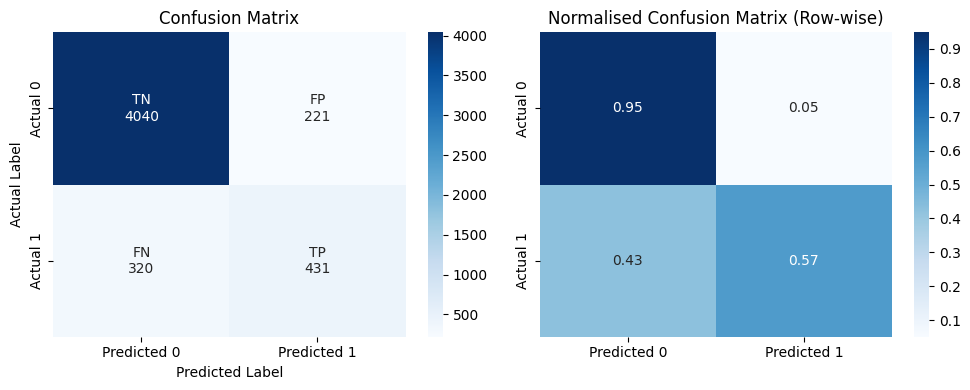

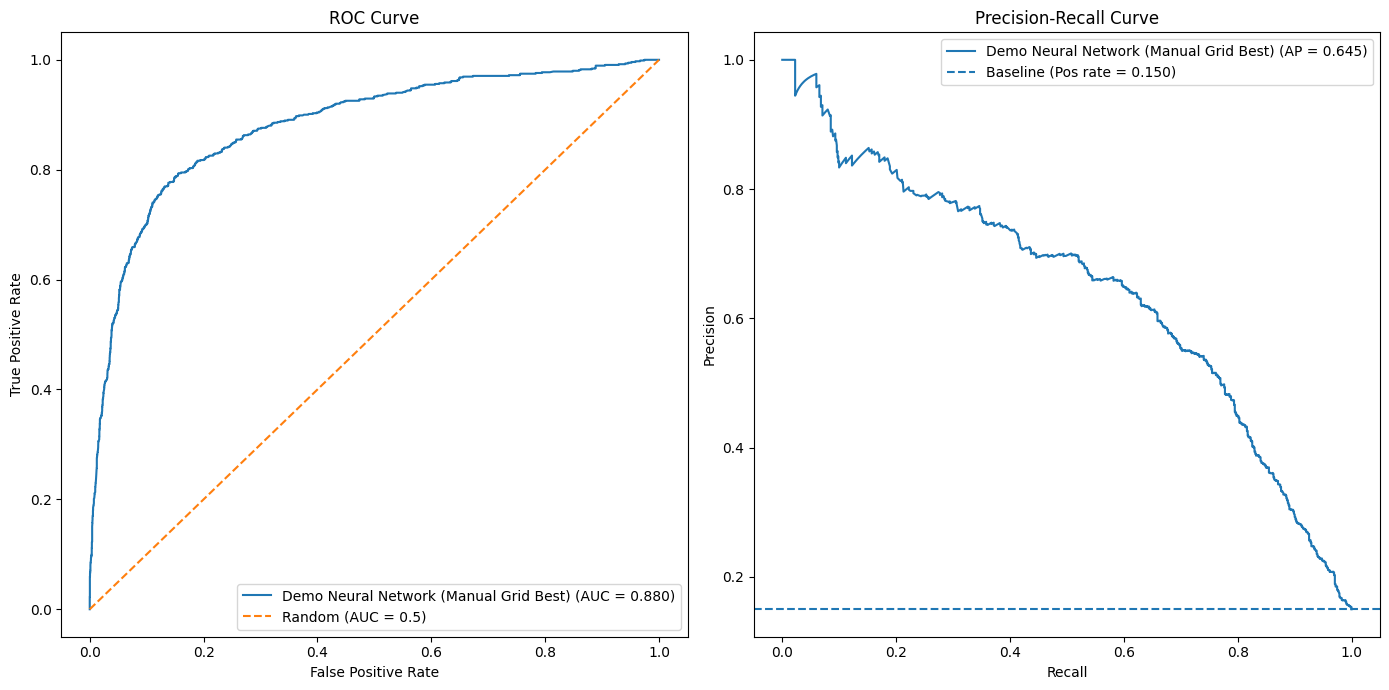

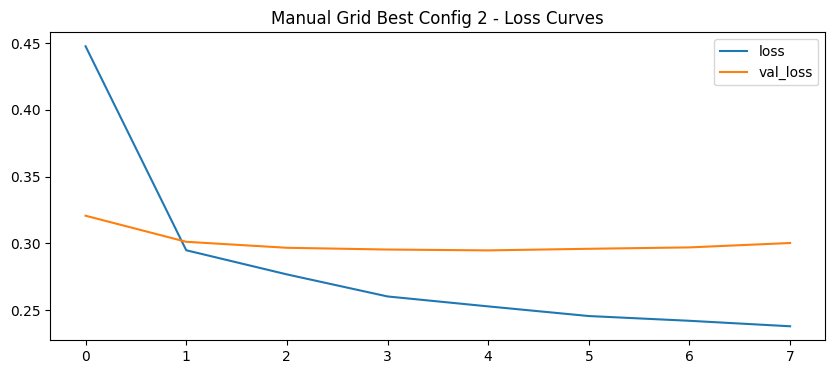

In [38]:
manual_grid = [
    {'config_idx': 1, 'units': 16, 'layers': 1, 'activation': 'relu', 'optimizer': 'adam', 'lr': 1e-3, 'dropout': 0.0, 'l2_strength': 0.0},
    {'config_idx': 2, 'units': 32, 'layers': 1, 'activation': 'relu', 'optimizer': 'adam', 'lr': 1e-3, 'dropout': 0.1, 'l2_strength': 0.0},
    {'config_idx': 3, 'units': 48, 'layers': 2, 'activation': 'relu', 'optimizer': 'adam', 'lr': 3e-4, 'dropout': 0.1, 'l2_strength': 1e-5},
]

manual_grid_results_path = DEMO_NN_GRID_SEARCH_DIR / 'demo_manual_nn_grid_search_results.csv'
manual_grid_results_json_path = DEMO_NN_GRID_SEARCH_DIR / 'demo_manual_nn_grid_search_results.json'
manual_grid_best_params_path = DEMO_NN_GRID_SEARCH_DIR / 'demo_best_params.json'

def run_manual_grid_search():
    manual_grid_results = []
    manual_grid_early_stop = KerasEarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=3,
        restore_best_weights=True,
        min_delta=1e-4,
    )

    # Train each configuration, then save the model file and history file separately.
    for config in manual_grid:
        tf.keras.backend.clear_session()
        set_seed(SEED)

        model = build_binary_classifier(
            input_dim=X_train_grid.shape[1],
            units=config['units'],
            layers=config['layers'],
            activation=config['activation'],
            optimizer=config['optimizer'],
            lr=config['lr'],
            dropout=config['dropout'],
            l2_strength=config['l2_strength'],
        )

        history = model.fit(
            X_train_grid,
            y_train_grid,
            validation_data=(X_val_grid, y_val_grid),
            epochs=MANUAL_GRID_EPOCHS,
            batch_size=MANUAL_GRID_BATCH_SIZE,
            callbacks=[manual_grid_early_stop],
            verbose=0,
            shuffle=False,
        )

        model_path = DEMO_NN_GRID_SEARCH_MODEL_DIR / f"demo_tuned_model_config_{config['config_idx']}.keras"
        history_path = DEMO_NN_GRID_SEARCH_HISTORY_DIR / f"demo_tuned_model_config_{config['config_idx']}_history.h5"
        model.save(model_path)
        pd.DataFrame(history.history).to_hdf(history_path, key='history', mode='w')

        y_prob_test = model.predict(X_test_s, verbose=0).ravel()
        manual_grid_results.append(
            {
                **config,
                'epochs_ran': len(history.history['loss']),
                'val_auc': float(np.max(history.history['val_auc'])),
                'test_auc': float(roc_auc_score(y_test, y_prob_test)),
                'model_path': to_artifact_reference(model_path),
                'history_path': to_artifact_reference(history_path),
            }
        )

    manual_grid_results_df = pd.DataFrame(manual_grid_results).sort_values('val_auc', ascending=False)
    manual_grid_results_df.to_csv(manual_grid_results_path, index=False)
    manual_grid_results_json_path.write_text(manual_grid_results_df.to_json(orient='records', indent=2), encoding='utf-8')
    save_json(
        manual_grid_best_params_path,
        {
            'best_params': manual_grid_results_df.iloc[0][['units', 'layers', 'activation', 'optimizer', 'lr', 'dropout', 'l2_strength']].to_dict(),
            'selected_config_idx': int(manual_grid_results_df.iloc[0]['config_idx']),
        },
    )
    return manual_grid_results_df

manual_grid_loaded = False

if OVERWRITE_NN_TUNING:
    print('OVERWRITE_NN_TUNING=True: running a fresh manual neural-network grid search.')
    manual_grid_results_df = run_manual_grid_search()
elif LOAD_NN_TUNING:
    try:
        manual_grid_results_df = pd.read_csv(manual_grid_results_path).sort_values('val_auc', ascending=False)
        best_manual_config = manual_grid_results_df.iloc[0]
        _ = load_model(resolve_artifact_reference(best_manual_config['model_path']))
        _ = pd.read_hdf(resolve_artifact_reference(best_manual_config['history_path']), key='history')
        manual_grid_loaded = True
        print(f'Loaded saved manual neural-network grid-search artefacts from {DEMO_NN_GRID_SEARCH_DIR}.')
    except Exception as e:
        print(f'Could not load saved manual neural-network grid-search artefacts: {e}')
        print('Running a fresh manual grid search and saving new artefacts.')
        manual_grid_results_df = run_manual_grid_search()
else:
    print('LOAD_NN_TUNING=False: running a fresh manual neural-network grid search.')
    manual_grid_results_df = run_manual_grid_search()

best_manual_config = manual_grid_results_df.sort_values('val_auc', ascending=False).iloc[0]
best_manual_model = load_model(resolve_artifact_reference(best_manual_config['model_path']))
best_manual_history = pd.read_hdf(resolve_artifact_reference(best_manual_config['history_path']), key='history')
y_prob_manual = best_manual_model.predict(X_test_s, verbose=0).ravel()
y_pred_manual = (y_prob_manual >= 0.5).astype(int)

results = evaluate_and_store_model(
    results,
    m_id=5,
    model_name='Manual Grid Best',
    model_type='Neural Network',
    stage='Demo',
    y_true=y_test,
    y_pred=y_pred_manual,
    y_prob=y_prob_manual,
    hyperparameters=best_manual_config[['units', 'layers', 'activation', 'optimizer', 'lr', 'dropout', 'l2_strength']].to_dict(),
    metadata={'threshold': 0.5, 'loaded_existing_tuning': manual_grid_loaded},
)

display(HTML('<div style="max-height:320px; overflow:auto;">' + manual_grid_results_df.to_html(index=False) + '</div>'))
display(
    pd.Series(
        {
            'results_csv_path': to_artifact_reference(manual_grid_results_path),
            'results_json_path': to_artifact_reference(manual_grid_results_json_path),
            'best_params_path': to_artifact_reference(manual_grid_best_params_path),
            'best_model_path': best_manual_config['model_path'],
            'best_history_path': best_manual_config['history_path'],
            'loaded_existing_tuning': manual_grid_loaded,
        }
    )
)

print_model_metrics(results, 5)
plot_model_confusion_matrix(results, 5)
plot_roc_and_pr_curves(build_models_to_plot(results, [5]), figsize=(14, 7))

best_manual_history[['loss', 'val_loss']].plot(figsize=(10, 4), title=f"Manual Grid Best Config {int(best_manual_config['config_idx'])} - Loss Curves");
plt.show()


## Summary

The final table lists the demo-only dataset, model, and tuning artefact locations created or reused by this notebook.

In [39]:
summary_rows = [
    {'section': 'Dataset copy', 'path': to_artifact_reference(dataset_copy_path), 'purpose': 'Demo CSV dataset copy under demo_artifacts/datasets/.'},
    {'section': 'Baseline XGBoost', 'path': to_artifact_reference(xgb_model_path), 'purpose': 'Demo baseline XGBoost model under demo_artifacts/models/xgboost/.'},
    {'section': 'GridSearchCV', 'path': to_artifact_reference(DEMO_GRIDSEARCH_DIR), 'purpose': 'Demo GridSearchCV artefacts under demo_artifacts/tuning/gridsearch/.'},
    {'section': 'Baseline neural network', 'path': to_artifact_reference(baseline_nn_model_path), 'purpose': 'Demo baseline Keras model under demo_artifacts/models/neural_network/.'},
    {'section': 'XGBoost tuning', 'path': to_artifact_reference(DEMO_XGB_TUNING_DIR), 'purpose': 'Demo Optuna tuning artefacts under demo_artifacts/tuning/xgboost/.'},
    {'section': 'XGBoost tuned model', 'path': to_artifact_reference(DEMO_XGB_MODEL_DIR / TUNING_ARTIFACT_FILENAMES['best_model_joblib']), 'purpose': 'Demo tuned XGBoost model under demo_artifacts/models/xgboost/.'},
    {'section': 'NN tuning', 'path': to_artifact_reference(DEMO_KERAS_TUNER_DIR), 'purpose': 'Demo Keras Tuner artefacts under demo_artifacts/tuning/keras_tuner/.'},
    {'section': 'NN tuned model', 'path': to_artifact_reference(DEMO_NN_MODEL_DIR / 'demo_best_model_training.keras'), 'purpose': 'Demo tuned Keras model under demo_artifacts/models/neural_network/.'},
]

display(pd.DataFrame(summary_rows))
print('Precedence rule confirmed: OVERWRITE > LOAD > TRAIN/RETUNE')
print('Demo outputs are written under the configured demo_artifacts root.')


,section,path,purpose
0,Dataset copy,demo_artifacts/datasets/Stage_1_public_demo_co...,Demo CSV dataset copy under demo_artifacts/dat...
1,Baseline XGBoost,demo_artifacts/models/xgboost/best_model.joblib,Demo baseline XGBoost model under demo_artifac...
2,GridSearchCV,demo_artifacts/tuning/gridsearch,Demo GridSearchCV artefacts under demo_artifac...
3,Baseline neural network,demo_artifacts/models/neural_network/demo_base...,Demo baseline Keras model under demo_artifacts...
4,XGBoost tuning,demo_artifacts/tuning/xgboost,Demo Optuna tuning artefacts under demo_artifa...
5,XGBoost tuned model,demo_artifacts/models/xgboost/best_model.joblib,Demo tuned XGBoost model under demo_artifacts/...
6,NN tuning,demo_artifacts/tuning/keras_tuner,Demo Keras Tuner artefacts under demo_artifact...
7,NN tuned model,demo_artifacts/models/neural_network/demo_best...,Demo tuned Keras model under demo_artifacts/mo...


Precedence rule confirmed: OVERWRITE > LOAD > TRAIN/RETUNE
Demo outputs are written under the configured demo_artifacts root.
